<a href="https://colab.research.google.com/github/sirwemahmody86-boop/Zaribar_BI_Project-/blob/main/zrebar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install earthengine-api geemap pandas matplotlib --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 21.2 MB/s eta 0:00:00


In [ ]:
# """
# تحلیل روند مساحت دریاچه زریبار (مریوان) با استفاده از Google Earth Engine
# ==========================================================================

# پیش‌نیازها:
#     pip install earthengine-api geemap pandas matplotlib

# قبل از اجرا:
#     1. یک حساب Google Earth Engine بساز: https://signup.earthengine.google.com
#     2. یکبار در ترمینال دستور زیر رو اجرا کن تا احراز هویت انجام بشه:
#            earthengine authenticate
#        (یا در کد از ee.Authenticate() استفاده کن)

# خروجی:
#     - فایل CSV با ستون‌های: تاریخ، مساحت آب (کیلومترمربع)
#     - نمودار روند مساحت آب در طول زمان
# """

import ee
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------------
# 1. اتصال و احراز هویت
# ---------------------------------------------------------------
EE_PROJECT_ID = 'gen-lang-client-0964680325'  # Project ID خودت

try:
    ee.Initialize(project=EE_PROJECT_ID)
except Exception:
    ee.Authenticate()
    ee.Initialize(project=EE_PROJECT_ID)

# ---------------------------------------------------------------
# 2. محدوده جغرافیایی دریاچه زریبار (مختصات دقیق‌شده)
#    مرکز واقعی دریاچه طبق منابع رسمی: ۳۵.۵۳۳ عرض، ۴۶.۱۳۳ طول جغرافیایی
#    مساحت متوسط دریاچه ~۸.۹ کیلومترمربع (طول ~۵ کیلومتر، عرض ~۱.۶ کیلومتر)
#    باکس زیر با حاشیه اطمینان دور دریاچه کشیده شده
# ---------------------------------------------------------------
zarivar_aoi = ee.Geometry.Rectangle([46.08, 35.49, 46.18, 35.57])

# ---------------------------------------------------------------
# 3. تابع محاسبه شاخص NDWI و استخراج مساحت آب از یک تصویر Landsat
#    NDWI = (Green - NIR) / (Green + NIR)
#    مقادیر بالای ۰ معمولاً نشان‌دهنده آب هستند (آستانه قابل تنظیم است)
# ---------------------------------------------------------------
def mask_clouds(image):
    """ماسک ابر و سایه با استفاده از باند QA_PIXEL (دقیق‌تر از فیلتر CLOUD_COVER کلی)"""
    qa = image.select('QA_PIXEL')
    # بیت ۳ = سایه ابر، بیت ۴ = برف، بیت ۵ = ابر
    cloud_shadow = 1 << 3
    snow = 1 << 4
    cloud = 1 << 5
    mask = (
        qa.bitwiseAnd(cloud_shadow).eq(0)
        .And(qa.bitwiseAnd(snow).eq(0))
        .And(qa.bitwiseAnd(cloud).eq(0))
    )
    return image.updateMask(mask)


def compute_water_area(image, aoi, threshold=0.0, scale=30):
    image = mask_clouds(image)
    ndwi = image.normalizedDifference(['SR_B3', 'SR_B5']).rename('NDWI')
    water_mask = ndwi.gt(threshold)
    area_image = water_mask.multiply(ee.Image.pixelArea())
    area = area_image.reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=aoi,
        scale=scale,
        maxPixels=1e9
    ).get('NDWI')
    return area  # به متر مربع

# ---------------------------------------------------------------
# 4. جمع‌آوری مجموعه تصاویر Landsat 8/9 (Surface Reflectance، از ۲۰۱۳ تا امروز)
#    برای بازه ۱۹۸۴-۲۰۱۳ باید از Landsat 5/7 با باندهای متفاوت استفاده کرد
#    (کد جدا نیاز است چون نام باندها فرق می‌کند: SR_B2/SR_B4 به‌جای SR_B3/SR_B5)
# ---------------------------------------------------------------
collection = (
    ee.ImageCollection('LANDSAT/LC08/C02/T1_L2')
    .merge(ee.ImageCollection('LANDSAT/LC09/C02/T1_L2'))
    .filterBounds(zarivar_aoi)
    .filterDate('2000-01-01', '2026-01-01')
    .filter(ee.Filter.lt('CLOUD_COVER', 20))  # حذف تصاویر پرابر
)

print(f"تعداد تصاویر یافت‌شده: {collection.size().getInfo()}")

# ---------------------------------------------------------------
# 5. اعمال scale factor استاندارد Landsat Collection 2 و محاسبه مساحت برای هر تصویر
# ---------------------------------------------------------------
def scale_image(image):
    optical = image.select('SR_B.').multiply(0.0000275).add(-0.2)
    return image.addBands(optical, None, True)

image_list = collection.map(scale_image).toList(collection.size())
n = image_list.size().getInfo()

records = []
for i in range(n):
    img = ee.Image(image_list.get(i))
    date = img.date().format('YYYY-MM-dd').getInfo()
    try:
        area_m2 = compute_water_area(img, zarivar_aoi).getInfo()
        if area_m2 is not None:
            records.append({
                'date': date,
                'water_area_km2': area_m2 / 1_000_000
            })
    except Exception as e:
        print(f"خطا برای تصویر {date}: {e}")

# ---------------------------------------------------------------
# 6. حذف داده‌های پرت (Outliers) — مساحت واقعی دریاچه حدود ۲ کیلومترمربعه
#    هر عدد غیرمنطقی (نویز ابر/برف که ماسک هم از دستش در رفته) کنار گذاشته می‌شه
# ---------------------------------------------------------------
df = pd.DataFrame(records)
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

SANITY_MAX_KM2 = 15  # مساحت متوسط واقعی ~۸.۹ کیلومترمربع؛ حاشیه برای نوسان فصلی/سیلاب
before = len(df)
df = df[df['water_area_km2'] <= SANITY_MAX_KM2].reset_index(drop=True)
print(f"\n{before - len(df)} رکورد پرت (outlier) حذف شد.")

df.to_csv('zarivar_lake_area.csv', index=False, encoding='utf-8-sig')
print(f"\n{len(df)} رکورد در zarivar_lake_area.csv ذخیره شد.")

# ---------------------------------------------------------------
# 7. رسم نمودار روند
# ---------------------------------------------------------------
plt.figure(figsize=(12, 6))
plt.plot(df['date'], df['water_area_km2'], marker='o', linestyle='-', markersize=3)
plt.title('روند مساحت آب دریاچه زریبار (2000 تا کنون)')
plt.xlabel('تاریخ')
plt.ylabel('مساحت (کیلومترمربع)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('zarivar_lake_trend.png', dpi=150)
plt.show()

print("\nنمودار در zarivar_lake_trend.png ذخیره شد.")
print("\nنکته: این CSV رو مستقیم می‌تونی به‌عنوان منبع داده در Power BI ایمپورت کنی")
print("(Get Data > Text/CSV) و روی همون روند، خط روند و فصلی‌سازی رو در Power BI بسازی.")

MessageError: Error: credential propagation was unsuccessful

In [ ]:
from google.colab import files
files.download('zarivar_lake_area.csv')

In [ ]:
# ================================================================
# استخراج بارش ماهانه (CHIRPS) برای منطقه دریاچه زریوار
# این کد رو توی یه سلول جدید توی همون نوت‌بوک Colab قبلی اجرا کن
# (بعد از اینکه ee.Authenticate() / ee.Initialize() قبلاً انجام شده باشه)
# ================================================================

import ee
import pandas as pd

# اگه توی این سشن Colab هنوز Earth Engine رو initialize نکردی:
# ee.Authenticate()
# ee.Initialize(project='YOUR-PROJECT-ID')   # همون project ID که برای NDWI استفاده کردی

# ---------------------------------------------------------------
# 1. اتصال و احراز هویت
# ---------------------------------------------------------------
# EE_PROJECT_ID = 'gen-lang-client-0964680325'  # Project ID خودت

# try:
#     ee.Initialize(project=EE_PROJECT_ID)
# except Exception:
#     ee.Authenticate()
#     ee.Initialize(project=EE_PROJECT_ID)

# ----------------------------------------------------------------
# ۱) همون geometry (محدوده) دریاچه که برای محاسبه مساحت آب استفاده کردی
#    اینجا رو با همون مختصات دقیق قبلی جایگزین کن تا هر دو تحلیل
#    دقیقاً روی یه منطقه‌ی یکسان انجام بشه
# ----------------------------------------------------------------
roi = ee.Geometry.Polygon([[
    [46.10, 35.50],
    [46.17, 35.50],
    [46.17, 35.56],
    [46.10, 35.56],
    [46.10, 35.50]
]])  # <-- جایگزین کن با مختصات polygon قبلی

# ----------------------------------------------------------------
# ۲) بازه زمانی — باید همون بازه‌ای باشه که برای مساحت آب استفاده کردی
# ----------------------------------------------------------------
start_year = 2013
end_year = 2026  # تا ابتدای این سال (یعنی آخرین ماه کامل، دسامبر سال قبل)

chirps = ee.ImageCollection('UCSB-CHG/CHIRPS/DAILY')

n_months = (end_year - start_year) * 12
months = ee.List.sequence(0, n_months - 1)

def monthly_precip(offset):
    offset = ee.Number(offset)
    start = ee.Date.fromYMD(start_year, 1, 1).advance(offset, 'month')
    end = start.advance(1, 'month')

    # جمع بارش روزانه در طول ماه = بارش کل ماه
    monthly_img = chirps.filterDate(start, end).sum()

    stats = monthly_img.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=roi,
        scale=5000,      # رزولوشن اصلی CHIRPS تقریباً ۵ کیلومتره
        maxPixels=1e9
    )

    return ee.Feature(None, {
        'date': start.format('YYYY-MM'),
        'precip_mm': stats.get('precipitation')
    })

monthly_fc = ee.FeatureCollection(months.map(monthly_precip))

# ----------------------------------------------------------------
# ۳) دریافت نتایج و تبدیل به DataFrame / CSV
# ----------------------------------------------------------------
features = monthly_fc.getInfo()['features']
rows = [f['properties'] for f in features]

df = pd.DataFrame(rows).sort_values('date').reset_index(drop=True)
df.to_csv('zarivar_precipitation.csv', index=False)

print(df.head())
print(f"\nتعداد رکوردها: {len(df)}")

# ----------------------------------------------------------------
# ۴) دانلود فایل CSV (مشابه کاری که برای مساحت آب انجام دادی)
# ----------------------------------------------------------------
from google.colab import files
files.download('zarivar_precipitation.csv')

In [ ]:
# =========================================================
# بخش ۱: ادغام فایل مساحت آب + بارش در یک فایل واحد
# =========================================================
# فرض: تا الان دو فایل داری:
#   - zarivar_water_area.csv   (ستون‌ها: date, area_km2  یا اسم مشابه)
#   - zarivar_precipitation.csv (ستون‌ها: date, precip_mm)
# اگه اسم ستون مساحتت فرق داره (مثلاً area یا water_area_km2)، همون‌جایی که
# نوشته 'area_km2' رو با اسم واقعی ستونت جایگزین کن.

import pandas as pd

# --- خواندن فایل‌ها ---
df_area = pd.read_csv('zarivar_water_area.csv')      # فایل مساحت آب (خروجی قبلی خودت)
df_precip = pd.read_csv('zarivar_precipitation.csv')  # فایل بارش (خروجی مرحله قبل)

# --- یکسان‌سازی فرمت تاریخ (مهم، چون merge روی این ستون انجام می‌شه) ---
df_area['date'] = pd.to_datetime(df_area['date']).dt.strftime('%Y-%m')
df_precip['date'] = pd.to_datetime(df_precip['date']).dt.strftime('%Y-%m')

# --- ادغام (merge) روی ستون تاریخ ---
df_merged = pd.merge(df_area, df_precip, on='date', how='outer')
df_merged = df_merged.sort_values('date').reset_index(drop=True)

# --- ذخیره فایل نهایی ---
df_merged.to_csv('zarivar_combined.csv', index=False)
print("فایل ترکیبی ساخته شد: zarivar_combined.csv")
print(df_merged.head())


# =========================================================
# بخش ۲: KPI شماره ۶ — داده GRACE برای تغییرات ذخیره آب زیرزمینی
# =========================================================
# نکته مهم درباره GRACE:
# - قدرت تفکیک مکانی GRACE خیلی پایینه (حدود ۱۰۰-۳۰۰ کیلومتر)، یعنی
#   نمی‌تونه دقیقاً فقط "زیر دریاچه زریوار" رو نشون بده؛ بلکه یه سیگنال
#   کلی برای کل منطقه غرب/شمال‌غرب ایران (حوضه بزرگ‌تر) می‌ده.
# - برای همین این KPI رو باید به عنوان "شاهد منطقه‌ای" (context) معرفی کنی
#   نه یه اندازه‌گیری دقیق محلی. مفیده برای دیدن روند کلی افت آبخوان
#   در سطح منطقه، که می‌تونه با افت چشمه‌های کف دریاچه هم‌خوانی داشته باشه.

import ee

# اگه قبلاً authenticate/initialize کردی این دو خط رو نیازی نیست دوباره اجرا کنی
# ee.Authenticate()
# ee.Initialize(project='YOUR_PROJECT_ID')

# --- محدوده وسیع‌تر برای GRACE (چون قدرت تفکیک پایینه، منطقه بزرگ‌تری لازمه) ---
# این یه باکس حدود ۱ درجه (~100 کیلومتر) دور دریاچه زریوارِ که می‌تونی
# بر اساس مختصات دقیق roi خودت تنظیمش کنی
grace_roi = ee.Geometry.Rectangle([45.5, 35.0, 46.5, 36.0])  # نمونه؛ تنظیم کن

# --- دیتاست GRACE (نسخه Mascon، ماهانه) ---
grace = ee.ImageCollection('NASA/GRACE/MASS_GRIDS_V04/MASCON') \
    .select('lwe_thickness')  # ضخامت معادل آب (liquid water equivalent) بر حسب سانتی‌متر

def get_grace_monthly(image):
    date = image.date().format('YYYY-MM')
    mean_val = image.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=grace_roi,
        scale=50000,  # قدرت تفکیک GRACE خیلی درشته، مقیاس بزرگ منطقی‌تره
        maxPixels=1e9
    ).get('lwe_thickness')
    return ee.Feature(None, {'date': date, 'lwe_cm': mean_val})

grace_features = grace.map(get_grace_monthly)
grace_fc = ee.FeatureCollection(grace_features)

# --- گرفتن نتیجه به صورت لیست و تبدیل به DataFrame ---
grace_list = grace_fc.getInfo()['features']
grace_data = [f['properties'] for f in grace_list]
df_grace = pd.DataFrame(grace_data)
df_grace = df_grace.dropna(subset=['lwe_cm'])
df_grace = df_grace.sort_values('date').reset_index(drop=True)

df_grace.to_csv('zarivar_grace.csv', index=False)
print("فایل GRACE ساخته شد: zarivar_grace.csv")
print(df_grace.head())

# --- ادغام نهایی همه چیز در یک فایل (مساحت + بارش + GRACE) ---
df_final = pd.merge(df_merged, df_grace, on='date', how='outer')
df_final = df_final.sort_values('date').reset_index(drop=True)
df_final.to_csv('zarivar_combined_all.csv', index=False)
print("فایل نهایی کامل ساخته شد: zarivar_combined_all.csv")
print(df_final.head())

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import pandas as pd

# --- خواندن فایل‌ها (با اسم درست) ---
df_area = pd.read_csv('zarivar_lake_area.csv')
df_precip = pd.read_csv('zarivar_precipitation.csv')

# --- چک کردن اسم ستون‌ها قبل از merge (خیلی مهم) ---
print("ستون‌های فایل مساحت:", df_area.columns.tolist())
print("ستون‌های فایل بارش:", df_precip.columns.tolist())

In [ ]:
import pandas as pd

# --- خواندن فایل‌ها ---
df_area = pd.read_csv('zarivar_lake_area.csv')       # ستون‌ها: date, water_area_km2
df_precip = pd.read_csv('zarivar_precipitation.csv')  # ستون‌ها: date, precip_mm

# --- یکسان‌سازی فرمت تاریخ به YYYY-MM ---
df_area['date'] = pd.to_datetime(df_area['date']).dt.strftime('%Y-%m')
df_precip['date'] = pd.to_datetime(df_precip['date']).dt.strftime('%Y-%m')

# --- نکته مهم: توی df_area ممکنه چند تصویر ماهواره‌ای در یک ماه باشه ---
# (مثلاً چند سنجش Landsat در همون ماه) -> باید میانگین بگیریم تا هر ماه فقط یک ردیف بشه
print("قبل از تجمیع، تعداد ردیف‌های area:", len(df_area))
df_area = df_area.groupby('date', as_index=False)['water_area_km2'].mean()
print("بعد از تجمیع (یک ردیف در هر ماه):", len(df_area))

# --- همین کار رو برای بارش هم انجام بده، محض احتیاط (اگه تکراری داشت) ---
df_precip = df_precip.groupby('date', as_index=False)['precip_mm'].mean()

# --- ادغام روی ستون date (حالا هر دو فایل یک ردیف در هر ماه دارن) ---
df_merged = pd.merge(df_area, df_precip, on='date', how='outer')
df_merged = df_merged.sort_values('date').reset_index(drop=True)

# --- ذخیره فایل نهایی ---
df_merged.to_csv('zarivar_combined.csv', index=False)
print("\nفایل ترکیبی ساخته شد: zarivar_combined.csv")
print(df_merged.head(15))
print(f"\nتعداد کل ردیف‌ها (باید مساوی تعداد ماه‌ها باشه): {len(df_merged)}")

# --- بررسی مقادیر خالی (NaN) ---
print("\nتعداد ماه‌هایی که مساحت آب ندارن (احتمالاً ابر پوشیده بوده):", df_merged['water_area_km2'].isna().sum())
print("تعداد ماه‌هایی که بارش ندارن:", df_merged['precip_mm'].isna().sum())

# --- دانلود فایل ---
from google.colab import files
files.download('zarivar_combined.csv')


In [ ]:
"""
تحلیل روند مساحت نیزار دریاچه زریبار (مریوان) با استفاده از Google Earth Engine
=================================================================================

این اسکریپت مشابه اسکریپت مساحت آب است، ولی به‌جای شاخص NDWI (تشخیص آب)
از شاخص NDVI (شاخص نرمال‌شده تفاضل گیاهی) برای تشخیص نیزار/گیاه آبزی استفاده می‌کند.

پیش‌نیازها: همان پکیج‌های اسکریپت قبلی (earthengine-api, pandas, matplotlib)

خروجی:
    - فایل CSV با ستون‌های: تاریخ، مساحت نیزار (کیلومترمربع)
    - نمودار روند مساحت نیزار در طول زمان
"""

import ee
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------------
# 1. اتصال و احراز هویت (همان پروژه قبلی)
# ---------------------------------------------------------------
EE_PROJECT_ID = 'gen-lang-client-0964680325'

try:
    ee.Initialize(project=EE_PROJECT_ID)
except Exception:
    ee.Authenticate()
    ee.Initialize(project=EE_PROJECT_ID)

# ---------------------------------------------------------------
# 2. محدوده جغرافیایی — این‌بار محدودتر از اسکریپت آب
#    باکس قبلی (۴۶.۰۸-۴۶.۱۸) زمین‌های کشاورزی اطراف را هم می‌گرفت که
#    نوسان فصلی کِشتشان با نیزار قاطی می‌شد. اینجا فقط حاشیه نزدیک دریاچه را می‌گیریم.
# ---------------------------------------------------------------
zaribar_aoi = ee.Geometry.Rectangle([46.09, 35.505, 46.155, 35.555])

# ---------------------------------------------------------------
# 3. ماسک ابر (همان تابع قبلی)
# ---------------------------------------------------------------
def mask_clouds(image):
    qa = image.select('QA_PIXEL')
    cloud_shadow = 1 << 3
    snow = 1 << 4
    cloud = 1 << 5
    mask = (
        qa.bitwiseAnd(cloud_shadow).eq(0)
        .And(qa.bitwiseAnd(snow).eq(0))
        .And(qa.bitwiseAnd(cloud).eq(0))
    )
    return image.updateMask(mask)


# ---------------------------------------------------------------
# 4. تابع محاسبه شاخص NDVI و استخراج مساحت نیزار
#    NDVI = (NIR - Red) / (NIR + Red)
#    برای نیزار/گیاه آبزی معمولاً بازه NDVI بین 0.15 تا 0.6 مناسب است
#    (پایین‌تر از این یعنی آب باز یا خاک لخت، بالاتر یعنی گیاه خشکی‌زی متراکم)
# ---------------------------------------------------------------
NDVI_LOW = 0.15
NDVI_HIGH = 0.60

def compute_reed_area(image, aoi, scale=30):
    image = mask_clouds(image)
    ndvi = image.normalizedDifference(['SR_B5', 'SR_B4']).rename('NDVI')
    reed_mask = ndvi.gt(NDVI_LOW).And(ndvi.lt(NDVI_HIGH))
    area_image = reed_mask.multiply(ee.Image.pixelArea())
    area = area_image.reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=aoi,
        scale=scale,
        maxPixels=1e9
    ).get('NDVI')
    return area  # به متر مربع


# ---------------------------------------------------------------
# 5. جمع‌آوری تصاویر (همان بازه و همان کالکشن اسکریپت آب)
# ---------------------------------------------------------------
collection = (
    ee.ImageCollection('LANDSAT/LC08/C02/T1_L2')
    .merge(ee.ImageCollection('LANDSAT/LC09/C02/T1_L2'))
    .filterBounds(zaribar_aoi)
    .filterDate('2013-01-01', '2026-01-01')
    .filter(ee.Filter.lt('CLOUD_COVER', 20))
)

print(f"تعداد تصاویر یافت‌شده: {collection.size().getInfo()}")

def scale_image(image):
    optical = image.select('SR_B.').multiply(0.0000275).add(-0.2)
    return image.addBands(optical, None, True)

image_list = collection.map(scale_image).toList(collection.size())
n = image_list.size().getInfo()

records = []
for i in range(n):
    img = ee.Image(image_list.get(i))
    date = img.date().format('YYYY-MM-dd').getInfo()
    try:
        area_m2 = compute_reed_area(img, zaribar_aoi).getInfo()
        if area_m2 is not None:
            records.append({
                'date': date,
                'reed_area_km2': area_m2 / 1_000_000
            })
    except Exception as e:
        print(f"خطا برای تصویر {date}: {e}")

# ---------------------------------------------------------------
# 6. حذف داده‌های پرت
#    نیزار نمی‌تواند بزرگ‌تر از کل محدوده دریاچه+حاشیه باشد؛
#    آستانه را با توجه به مساحت باکس (~۷۵ کیلومترمربع) محافظه‌کارانه می‌گذاریم
# ---------------------------------------------------------------
df = pd.DataFrame(records)
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

SANITY_MAX_KM2 = 10
before = len(df)
df = df[df['reed_area_km2'] <= SANITY_MAX_KM2].reset_index(drop=True)
print(f"\n{before - len(df)} رکورد پرت (outlier) حذف شد.")

df.to_csv('zaribar_reed_area.csv', index=False, encoding='utf-8-sig')
print(f"\n{len(df)} رکورد در zaribar_reed_area.csv ذخیره شد.")

# ---------------------------------------------------------------
# 7. رسم نمودار روند
# ---------------------------------------------------------------
plt.figure(figsize=(12, 6))
plt.plot(df['date'], df['reed_area_km2'], marker='o', linestyle='-', markersize=3, color='green')
plt.title('روند مساحت نیزار دریاچه زریبار (۲۰۱۳ تا کنون)')
plt.xlabel('تاریخ')
plt.ylabel('مساحت نیزار (کیلومترمربع)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('zaribar_reed_trend.png', dpi=150)
plt.show()

print("\nنمودار در zaribar_reed_trend.png ذخیره شد.")
print("\nنکته: این CSV رو می‌تونی بر اساس تاریخ با zarivar_lake_area.csv")
print("(داده مساحت آب) در Power BI ترکیب کنی و نسبت آب باز به نیزار رو بسازی.")

In [ ]:
from google.colab import files
files.download('zaribar_reed_area.csv')

In [ ]:
import os
print(os.listdir('.'))

In [ ]:
# ================================================================
# طبقه‌بندی سالانه آب باز / نیزار / خشکی برای دریاچه زریوار
# با Sentinel-2 (وضوح ۱۰ متر) + کامپوزیت میانه سالانه + s2cloudless
# ================================================================

import ee
import pandas as pd

# اگه Earth Engine قبلاً initialize نشده:
# ee.Authenticate()
# ee.Initialize(project='YOUR-PROJECT-ID')

# ----------------------------------------------------------------
# ۱) همون geometry دقیق دور دریاچه که قبلاً استفاده کردی
# ----------------------------------------------------------------
roi = ee.Geometry.Polygon([[
    [46.10, 35.50],
    [46.17, 35.50],
    [46.17, 35.56],
    [46.10, 35.56],
    [46.10, 35.50]
]])  # <-- جایگزین کن با مختصات دقیق قبلی

# ⚠️ Sentinel-2 فقط از اواسط ۲۰۱۵ به بعد داده معتبر داره
# (سال‌های ۲۰۱۳-۲۰۱۴ همچنان فقط با Landsat قابل بررسی‌ان و
#  باید جدا و با روش قبلی تحلیل بشن)
start_year = 2016
end_year = 2025  # شامل تا انتهای ۲۰۲۴؛ اگه ۲۰۲۵ ناقصه جدا حسابش کن

s2 = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
s2_clouds = ee.ImageCollection('COPERNICUS/S2_CLOUD_PROBABILITY')
def mask_clouds(img):
    cloud_prob = ee.Image(img.get('cloud_mask')).select('probability')
    is_clear = cloud_prob.lt(40)
    return (img.select(['B3', 'B4', 'B8'])
               .updateMask(is_clear)
               .divide(10000)
               .copyProperties(img, ['system:time_start']))


def get_year_composite(year):
    start = ee.Date.fromYMD(year, 1, 1)
    end = start.advance(1, 'year')

    s2_filtered = s2.filterDate(start, end).filterBounds(roi)
    clouds_filtered = s2_clouds.filterDate(start, end).filterBounds(roi)

    joined = ee.Join.saveFirst('cloud_mask').apply(
        primary=s2_filtered,
        secondary=clouds_filtered,
        condition=ee.Filter.equals(leftField='system:index', rightField='system:index')
    )

    composite = ee.ImageCollection(joined).map(mask_clouds).median().clip(roi)
    return composite


def classify_year(year):
    img = get_year_composite(year)

    ndwi = img.normalizedDifference(['B3', 'B8']).rename('NDWI')  # سبز - مادون‌قرمزنزدیک
    ndvi = img.normalizedDifference(['B8', 'B4']).rename('NDVI')  # مادون‌قرمزنزدیک - قرمز

    # آستانه‌های شروع — این‌ها رو با توجه به دانش محلی خودت
    # از روی خروجی واقعی تنظیم/اصلاح کن
    water_mask = ndwi.gt(0.2)
    reed_mask = ndwi.gt(-0.1).And(ndwi.lte(0.2)).And(ndvi.gt(0.25))
    dry_mask = water_mask.Not().And(reed_mask.Not())

    pixel_area = ee.Image.pixelArea()

    def area_km2(mask):
        stats = pixel_area.updateMask(mask).reduceRegion(
            reducer=ee.Reducer.sum(),
            geometry=roi,
            scale=10,
            maxPixels=1e9
        )
        return ee.Number(stats.get('area')).divide(1e6)  # m² -> km²

    return ee.Feature(None, {
        'year': year,
        'water_area_km2': area_km2(water_mask),
        'reed_area_km2': area_km2(reed_mask),
        'dry_area_km2': area_km2(dry_mask)
    })


features = [classify_year(y) for y in range(start_year, end_year)]
fc = ee.FeatureCollection(features)

results = fc.getInfo()['features']
rows = [f['properties'] for f in results]
df = pd.DataFrame(rows).sort_values('year').reset_index(drop=True)
df.to_csv('zarivar_annual_classification.csv', index=False)

print(df)

from google.colab import files
files.download('zarivar_annual_classification.csv')

In [ ]:
# ================================================================
# طبقه‌بندی سالانه آب باز / نیزار / خشکی برای دریاچه زریوار
# با Sentinel-2 (وضوح ۱۰ متر) + کامپوزیت میانه سالانه + s2cloudless
# نسخه اصلاح‌شده: مشکل ترتیب باندها و باند B2 گمشده حل شده
# ================================================================

import ee
import pandas as pd

# اگه Earth Engine قبلاً initialize نشده:
# ee.Authenticate()
# ee.Initialize(project='YOUR-PROJECT-ID')

# ----------------------------------------------------------------
# ۱) همون geometry دقیق دور دریاچه که قبلاً استفاده کردی
# ----------------------------------------------------------------
roi = ee.Geometry.Polygon([[
    [46.10, 35.50],
    [46.17, 35.50],
    [46.17, 35.56],
    [46.10, 35.56],
    [46.10, 35.50]
]])  # <-- جایگزین کن با مختصات دقیق قبلی

# ⚠️ Sentinel-2 فقط از اواسط ۲۰۱۵ به بعد داده معتبر داره
# (سال‌های ۲۰۱۳-۲۰۱۵ همچنان فقط با Landsat قابل بررسی‌ان)
start_year = 2016
end_year = 2025  # شامل تا انتهای ۲۰۲۴؛ اگه ۲۰۲۵ ناقصه جدا حسابش کن

s2 = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
s2_clouds = ee.ImageCollection('COPERNICUS/S2_CLOUD_PROBABILITY')


def mask_clouds(img):
    cloud_prob = ee.Image(img.get('cloud_mask')).select('probability')
    is_clear = cloud_prob.lt(40)  # کمتر از ۴۰٪ احتمال ابر = پیکسل قابل‌قبول
    return (img.select(['B2', 'B3', 'B4', 'B8'])   # <-- FIX: انتخاب زودهنگام باندها (حل مشکل ترتیب) + اضافه شدن B2 برای نمایش RGB
               .updateMask(is_clear)
               .divide(10000)
               .copyProperties(img, ['system:time_start']))


def get_year_composite(year):
    start = ee.Date.fromYMD(year, 1, 1)
    end = start.advance(1, 'year')

    s2_filtered = s2.filterDate(start, end).filterBounds(roi)
    clouds_filtered = s2_clouds.filterDate(start, end).filterBounds(roi)

    joined = ee.Join.saveFirst('cloud_mask').apply(
        primary=s2_filtered,
        secondary=clouds_filtered,
        condition=ee.Filter.equals(leftField='system:index', rightField='system:index')
    )

    composite = ee.ImageCollection(joined).map(mask_clouds).median().clip(roi)
    return composite


def classify_year(year):
    img = get_year_composite(year)

    ndwi = img.normalizedDifference(['B3', 'B8']).rename('NDWI')  # سبز - مادون‌قرمزنزدیک
    ndvi = img.normalizedDifference(['B8', 'B4']).rename('NDVI')  # مادون‌قرمزنزدیک - قرمز

    # آستانه‌های شروع — با توجه به دانش محلی خودت از روی خروجی واقعی تنظیم کن
    water_mask = ndwi.gt(0.2)
    reed_mask = ndwi.gt(-0.1).And(ndwi.lte(0.2)).And(ndvi.gt(0.25))
    dry_mask = water_mask.Not().And(reed_mask.Not())

    pixel_area = ee.Image.pixelArea()

    def area_km2(mask):
        stats = pixel_area.updateMask(mask).reduceRegion(
            reducer=ee.Reducer.sum(),
            geometry=roi,
            scale=10,
            maxPixels=1e9
        )
        return ee.Number(stats.get('area')).divide(1e6)  # m² -> km²

    return ee.Feature(None, {
        'year': year,
        'water_area_km2': area_km2(water_mask),
        'reed_area_km2': area_km2(reed_mask),
        'dry_area_km2': area_km2(dry_mask)
    })


features = [classify_year(y) for y in range(start_year, end_year)]
fc = ee.FeatureCollection(features)

results = fc.getInfo()['features']
rows = [f['properties'] for f in results]
df = pd.DataFrame(rows).sort_values('year').reset_index(drop=True)
df.to_csv('zarivar_annual_classification.csv', index=False)

print(df)

from google.colab import files
files.download('zarivar_annual_classification.csv')


# ================================================================
# بخش اختیاری: نمایش بصری طبقه‌بندی روی نقشه (برای بررسی چشمی آستانه‌ها)
# اگه می‌خوای نقشه رو ببینی، فقط خط‌های زیر رو از حالت کامنت دربیار
# و اجرا کن (بعد از اجرای کامل بخش بالا)
# ================================================================

# !pip install geemap -q
# import geemap
#
# year_to_check = 2024  # هر سالی که می‌خوای رو اینجا عوض کن
# img = get_year_composite(year_to_check)
# ndwi = img.normalizedDifference(['B3', 'B8']).rename('NDWI')
# ndvi = img.normalizedDifference(['B8', 'B4']).rename('NDVI')
#
# water_mask = ndwi.gt(0.2)
# reed_mask = ndwi.gt(-0.1).And(ndwi.lte(0.2)).And(ndvi.gt(0.25))
#
# classified = ee.Image(0).where(water_mask, 1).where(reed_mask, 2).selfMask()
# vis_params = {'min': 1, 'max': 2, 'palette': ['0000FF', '00FF00']}  # آبی=آب، سبز=نیزار
#
# Map = geemap.Map()
# Map.centerObject(roi, 14)
# Map.addLayer(img.select(['B4', 'B3', 'B2']), {'min': 0, 'max': 0.3}, 'تصویر واقعی (RGB)')
# Map.addLayer(classified, vis_params, 'طبقه‌بندی (آبی=آب, سبز=نیزار)')
# Map

In [ ]:
# ================================================================
# نمایش تصاویر با روش ساده و مطمئن (بدون geemap/folium)
# این کد رو توی یه سلول جدید اجرا کن (بعد از اجرای اسکریپت اصلی)
# ================================================================

from IPython.display import Image, display

year_to_check = 2024  # هر سالی که می‌خوای رو اینجا عوض کن

img = get_year_composite(year_to_check)
ndwi = img.normalizedDifference(['B3', 'B8']).rename('NDWI')
ndvi = img.normalizedDifference(['B8', 'B4']).rename('NDVI')

water_mask = ndwi.gt(0.2)
reed_mask = ndwi.gt(-0.1).And(ndwi.lte(0.2)).And(ndvi.gt(0.25))

classified = ee.Image(0).where(water_mask, 1).where(reed_mask, 2).selfMask()

# تصویر واقعی (RGB)
rgb_url = img.select(['B4', 'B3', 'B2']).getThumbURL({
    'region': roi,
    'dimensions': 600,
    'min': 0,
    'max': 0.3
})

# تصویر طبقه‌بندی‌شده (آبی=آب, سبز=نیزار)
class_url = classified.getThumbURL({
    'region': roi,
    'dimensions': 600,
    'min': 1,
    'max': 2,
    'palette': ['0000FF', '00FF00']
})

print(f"سال {year_to_check} — تصویر واقعی (RGB):")
display(Image(url=rgb_url))

print(f"\nسال {year_to_check} — طبقه‌بندی (آبی=آب، سبز=نیزار):")
display(Image(url=class_url))

In [ ]:
# ================================================================
# نسخه اصلاح‌شده تشخیص نیزار — با باندهای Sentinel-2 (B2,B3,B4,B8)
# این سلول خودکفاست: فقط نیاز به roi و تابع get_year_composite() داره
# که قبلاً توی نوت‌بوکت تعریف کردی
# ================================================================

from IPython.display import Image, display

year_to_check = 2024  # هر سالی که می‌خوای رو اینجا عوض کن

img = get_year_composite(year_to_check)
ndwi = img.normalizedDifference(['B3', 'B8']).rename('NDWI')
ndvi = img.normalizedDifference(['B8', 'B4']).rename('NDVI')

# =========================================================
# مرحله ۱: آب باز مطمئن (آستانه بالا، بدون ابهام)
# =========================================================
water_mask_raw = ndwi.gt(0.2)

# =========================================================
# مرحله ۲: حاشیه ۳۰۰ متری اطراف آب باز (Sentinel-2 = 10 متر/پیکسل -> شعاع 30 پیکسل)
# =========================================================
water_buffer = water_mask_raw.focal_max(radius=30, units='pixels')

# =========================================================
# مرحله ۳: نیزار = NDVI بالا، فقط داخل حاشیه نزدیک آب
# (این‌طوری مزرعه‌های دور از دریاچه با NDVI بالا اشتباهی نیزار حساب نمی‌شن)
# =========================================================
reed_mask = ndvi.gt(0.15).And(water_buffer)

# =========================================================
# مرحله ۴: آب باز واقعی = آب منهای نیزار غرق‌شده
# (نیزار غرق‌شده NDWI بالا داره، پس باید از آب باز کم بشه)
# =========================================================
water_mask = water_mask_raw.And(reed_mask.Not())

classified = ee.Image(0).where(water_mask, 1).where(reed_mask, 2).selfMask()

# =========================================================
# مرحله ۵: محاسبه مساحت هر کلاس
# =========================================================
pixel_area = ee.Image.pixelArea()

water_stats = water_mask.multiply(pixel_area).reduceRegion(
    reducer=ee.Reducer.sum(), geometry=roi, scale=10, maxPixels=1e9
).getInfo()
reed_stats = reed_mask.multiply(pixel_area).reduceRegion(
    reducer=ee.Reducer.sum(), geometry=roi, scale=10, maxPixels=1e9
).getInfo()

water_km2 = list(water_stats.values())[0] / 1e6
reed_km2 = list(reed_stats.values())[0] / 1e6

print(f"سال {year_to_check}")
print(f"مساحت آب باز واقعی: {water_km2:.3f} کیلومترمربع")
print(f"مساحت نیزار: {reed_km2:.3f} کیلومترمربع")

# =========================================================
# مرحله ۶: نمایش تصویری برای بررسی چشمی
# =========================================================
rgb_url = img.select(['B4', 'B3', 'B2']).getThumbURL({
    'region': roi, 'dimensions': 600, 'min': 0, 'max': 0.3
})

class_url = classified.getThumbURL({
    'region': roi, 'dimensions': 600, 'min': 1, 'max': 2,
    'palette': ['0000FF', '00FF00']
})

print(f"\nسال {year_to_check} — تصویر واقعی (RGB):")
display(Image(url=rgb_url))

print(f"\nسال {year_to_check} — طبقه‌بندی اصلاح‌شده (آبی=آب، سبز=نیزار):")
display(Image(url=class_url))

In [ ]:
# ================================================================
# نسخه اصلاح‌شده تشخیص نیزار — با باندهای Sentinel-2 (B2,B3,B4,B8)
# این سلول خودکفاست: فقط نیاز به roi و تابع get_year_composite() داره
# که قبلاً توی نوت‌بوکت تعریف کردی
# ================================================================

from IPython.display import Image, display

year_to_check = 2024  # هر سالی که می‌خوای رو اینجا عوض کن

img = get_year_composite(year_to_check)
ndwi = img.normalizedDifference(['B3', 'B8']).rename('NDWI')
ndvi = img.normalizedDifference(['B8', 'B4']).rename('NDVI')

# =========================================================
# مرحله ۱: آب باز مطمئن (آستانه بالا، بدون ابهام)
# =========================================================
water_mask_raw = ndwi.gt(0.2)

# =========================================================
# مرحله ۲: حاشیه ۱۵۰ متری اطراف آب باز (کوچیک‌تر از قبل، چون ۳۰۰ متر
# باعث می‌شد تپه‌های خشک اطراف هم داخل محدوده‌ی بررسی بیفتن)
# =========================================================
water_buffer = water_mask_raw.focal_max(radius=15, units='pixels')  # 15 پیکسل × 10م = 150م

# =========================================================
# مرحله ۳: نیزار = NDVI بالا + رطوبت کافی (NDWI نه خیلی منفی) + داخل حاشیه
# شرط NDWI اینجا فیلتر کلیدیه: زمین خشک اطراف دریاچه NDWI خیلی منفی داره
# (مثلاً زیر -0.3)، ولی نیزار/مرداب چون هنوز مرطوبه معمولاً بین -0.2 تا 0.2 می‌مونه
# =========================================================
reed_mask = ndvi.gt(0.15).And(ndwi.gt(-0.2)).And(water_buffer)

# =========================================================
# مرحله ۴: آب باز واقعی = آب منهای نیزار غرق‌شده
# (نیزار غرق‌شده NDWI بالا داره، پس باید از آب باز کم بشه)
# =========================================================
water_mask = water_mask_raw.And(reed_mask.Not())

classified = ee.Image(0).where(water_mask, 1).where(reed_mask, 2).selfMask()

# =========================================================
# مرحله ۵: محاسبه مساحت هر کلاس
# =========================================================
pixel_area = ee.Image.pixelArea()

water_stats = water_mask.multiply(pixel_area).reduceRegion(
    reducer=ee.Reducer.sum(), geometry=roi, scale=10, maxPixels=1e9
).getInfo()
reed_stats = reed_mask.multiply(pixel_area).reduceRegion(
    reducer=ee.Reducer.sum(), geometry=roi, scale=10, maxPixels=1e9
).getInfo()

water_km2 = list(water_stats.values())[0] / 1e6
reed_km2 = list(reed_stats.values())[0] / 1e6

print(f"سال {year_to_check}")
print(f"مساحت آب باز واقعی: {water_km2:.3f} کیلومترمربع")
print(f"مساحت نیزار: {reed_km2:.3f} کیلومترمربع")

# =========================================================
# مرحله ۶: نمایش تصویری برای بررسی چشمی
# =========================================================
rgb_url = img.select(['B4', 'B3', 'B2']).getThumbURL({
    'region': roi, 'dimensions': 600, 'min': 0, 'max': 0.3
})

class_url = classified.getThumbURL({
    'region': roi, 'dimensions': 600, 'min': 1, 'max': 2,
    'palette': ['0000FF', '00FF00']
})

print(f"\nسال {year_to_check} — تصویر واقعی (RGB):")
display(Image(url=rgb_url))

print(f"\nسال {year_to_check} — طبقه‌بندی اصلاح‌شده (آبی=آب، سبز=نیزار):")
display(Image(url=class_url))

In [ ]:
# ================================================================
# نسخه اصلاح‌شده تشخیص نیزار — با باندهای Sentinel-2 (B2,B3,B4,B8)
# این سلول خودکفاست: فقط نیاز به roi و تابع get_year_composite() داره
# که قبلاً توی نوت‌بوکت تعریف کردی
# ================================================================

from IPython.display import Image, display

year_to_check = 2024  # هر سالی که می‌خوای رو اینجا عوض کن

img = get_year_composite(year_to_check)
ndwi = img.normalizedDifference(['B3', 'B8']).rename('NDWI')
ndvi = img.normalizedDifference(['B8', 'B4']).rename('NDVI')

# =========================================================
# مرحله ۱: آب باز مطمئن (آستانه بالا، بدون ابهام)
# =========================================================
water_mask_raw = ndwi.gt(0.2)

# =========================================================
# مرحله ۲: حاشیه ۲۰۰ متری اطراف آب باز (بین دو حالت قبلی: نه ۳۰۰، نه ۱۵۰)
# =========================================================
water_buffer = water_mask_raw.focal_max(radius=20, units='pixels')  # 20 پیکسل × 10م = 200م

# =========================================================
# مرحله ۳: نیزار = NDVI متوسط‌به‌بالا + رطوبت (بازه‌ی وسیع‌تر NDWI) + داخل حاشیه
# نسبت به تلاش قبلی: NDVI رو شل‌تر کردیم (0.1 به‌جای 0.15) و کف NDWI رو
# پایین‌تر بردیم (-0.3 به‌جای -0.2) تا نیزار کم‌تراکم‌تر هم گرفته بشه
# =========================================================
reed_mask = ndvi.gt(0.1).And(ndwi.gt(-0.3)).And(water_buffer)

# =========================================================
# مرحله ۴: آب باز واقعی = آب منهای نیزار غرق‌شده
# (نیزار غرق‌شده NDWI بالا داره، پس باید از آب باز کم بشه)
# =========================================================
water_mask = water_mask_raw.And(reed_mask.Not())

classified = ee.Image(0).where(water_mask, 1).where(reed_mask, 2).selfMask()

# =========================================================
# مرحله ۵: محاسبه مساحت هر کلاس
# =========================================================
pixel_area = ee.Image.pixelArea()

water_stats = water_mask.multiply(pixel_area).reduceRegion(
    reducer=ee.Reducer.sum(), geometry=roi, scale=10, maxPixels=1e9
).getInfo()
reed_stats = reed_mask.multiply(pixel_area).reduceRegion(
    reducer=ee.Reducer.sum(), geometry=roi, scale=10, maxPixels=1e9
).getInfo()

water_km2 = list(water_stats.values())[0] / 1e6
reed_km2 = list(reed_stats.values())[0] / 1e6

print(f"سال {year_to_check}")
print(f"مساحت آب باز واقعی: {water_km2:.3f} کیلومترمربع")
print(f"مساحت نیزار: {reed_km2:.3f} کیلومترمربع")

# =========================================================
# مرحله ۶: نمایش تصویری برای بررسی چشمی
# =========================================================
rgb_url = img.select(['B4', 'B3', 'B2']).getThumbURL({
    'region': roi, 'dimensions': 600, 'min': 0, 'max': 0.3
})

class_url = classified.getThumbURL({
    'region': roi, 'dimensions': 600, 'min': 1, 'max': 2,
    'palette': ['0000FF', '00FF00']
})

print(f"\nسال {year_to_check} — تصویر واقعی (RGB):")
display(Image(url=rgb_url))

print(f"\nسال {year_to_check} — طبقه‌بندی اصلاح‌شده (آبی=آب، سبز=نیزار):")
display(Image(url=class_url))

2017: آب=7.58 km²  نیزار=2.59 km²  (از 18 تصویر)
2018: آب=7.62 km²  نیزار=2.96 km²  (از 20 تصویر)
2019: آب=7.77 km²  نیزار=2.31 km²  (از 35 تصویر)
2020: آب=7.54 km²  نیزار=2.82 km²  (از 36 تصویر)
2021: آب=7.67 km²  نیزار=3.22 km²  (از 36 تصویر)
2022: آب=7.45 km²  نیزار=3.24 km²  (از 36 تصویر)
2023: آب=7.34 km²  نیزار=2.80 km²  (از 33 تصویر)
2024: آب=7.04 km²  نیزار=2.99 km²  (از 35 تصویر)
2025: آب=7.70 km²  نیزار=2.82 km²  (از 54 تصویر)

9 سال در zaribar_reed_v2.csv ذخیره شد.
 year  n_images  water_area_km2  reed_area_km2  reed_to_water_ratio
 2017        18           7.578          2.588                0.342
 2018        20           7.621          2.958                0.388
 2019        35           7.772          2.312                0.297
 2020        36           7.536          2.822                0.374
 2021        36           7.666          3.222                0.420
 2022        36           7.445          3.238                0.435
 2023        33           7.341          2.

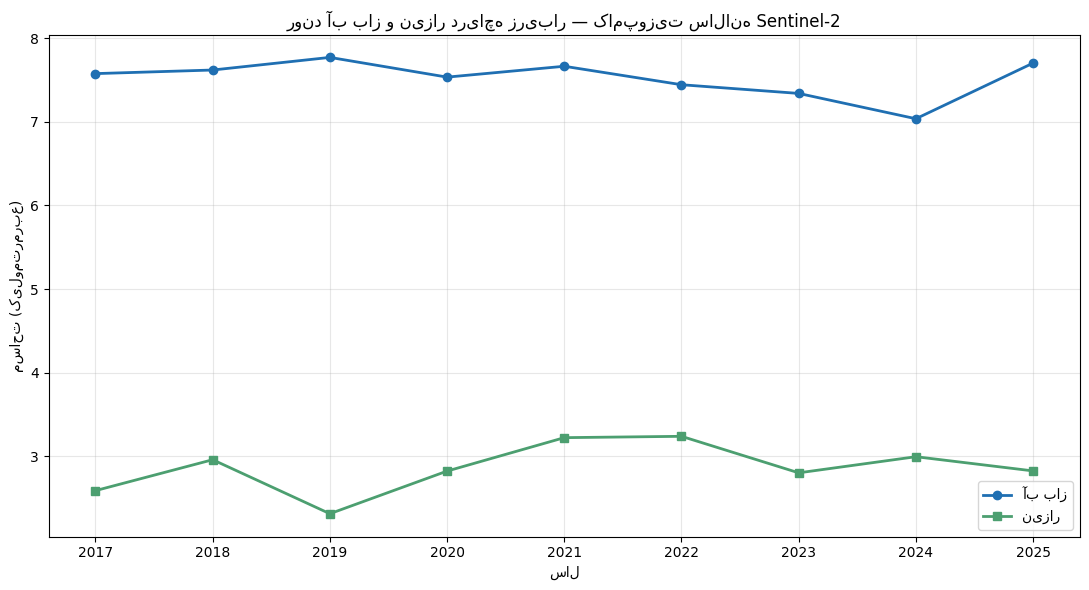

In [ ]:
"""
تحلیل دقیق روند نیزار دریاچه زریبار — نسخه ۲
==============================================

تفاوت‌های این نسخه با نسخه قبلی (که نتیجه نویزی داد):

۱. Sentinel-2 به‌جای Landsat  → پیکسل ۱۰ متری به‌جای ۳۰ متری (۹ برابر دقت بیشتر)
۲. کامپوزیت سالانه (میانه) به‌جای تک‌تک تصاویر → نویز ابر/سایه عملاً حذف می‌شود
۳. پنجره زمانی مرداد–مهر (اوج رشد نیزار) → مقایسه سال‌به‌سال در شرایط یکسان
۴. طبقه‌بندی سه‌کلاسه با ترکیب NDWI و NDVI → نیزار از آب باز و از مزرعه جدا می‌شود

خروجی: یک ردیف برای هر سال، شامل مساحت آب باز، مساحت نیزار، و نسبت آنها

محدودیت مهم: داده Sentinel-2 SR از ۲۰۱۷ به بعد موجود است،
بنابراین سال پایه این تحلیل ۲۰۱۷ است، نه ۲۰۱۳.
"""

import ee
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------------------------------------------
# ۱. اتصال
# ----------------------------------------------------------------
EE_PROJECT_ID = 'gen-lang-client-0964680325'

try:
    ee.Initialize(project=EE_PROJECT_ID)
except Exception:
    ee.Authenticate()
    ee.Initialize(project=EE_PROJECT_ID)

# ----------------------------------------------------------------
# ۲. محدوده — همان محدوده دریاچه زریبار
# ----------------------------------------------------------------
AOI = ee.Geometry.Rectangle([46.09, 35.505, 46.155, 35.555])

# ----------------------------------------------------------------
# ۳. ماسک ابر برای Sentinel-2 (باند SCL: طبقه‌بندی صحنه)
#    کلاس ۳=سایه ابر، ۸،۹،۱۰=ابر، ۱۱=برف
# ----------------------------------------------------------------
def mask_s2(image):
    scl = image.select('SCL')
    mask = (
        scl.neq(3)
        .And(scl.neq(8))
        .And(scl.neq(9))
        .And(scl.neq(10))
        .And(scl.neq(11))
    )
    return image.updateMask(mask).divide(10000)

# ----------------------------------------------------------------
# ۴. آستانه‌های طبقه‌بندی — این‌ها را بعد از دیدن نتیجه می‌توان تنظیم کرد
# ----------------------------------------------------------------
WATER_NDWI = 0.25     # بالاتر از این = آب باز
REED_NDVI_MIN = 0.20  # نیزار: پوشش گیاهی مشخص
REED_NDWI_MIN = -0.40 # ولی هنوز رطوبت دارد (برخلاف مزرعه خشک تابستان)

START_YEAR = 2017
END_YEAR = 2025

records = []

for year in range(START_YEAR, END_YEAR + 1):
    # پنجره اوج رشد نیزار: مرداد تا مهر (اواسط تابستان تا اوایل پاییز)
    col = (
        ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
        .filterBounds(AOI)
        .filterDate(f'{year}-07-15', f'{year}-10-15')
        .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 40))
        .map(mask_s2)
    )

    n_images = col.size().getInfo()
    if n_images == 0:
        print(f"{year}: تصویری یافت نشد")
        continue

    # کامپوزیت میانه — نویز ابر/سایه باقی‌مانده را حذف می‌کند
    composite = col.median()

    ndwi = composite.normalizedDifference(['B3', 'B8']).rename('NDWI')
    ndvi = composite.normalizedDifference(['B8', 'B4']).rename('NDVI')

    # کلاس ۱: آب باز
    water = ndwi.gt(WATER_NDWI)

    # کلاس ۲: نیزار — گیاه سبز + رطوبت، ولی آب باز نیست
    reed = (
        ndvi.gt(REED_NDVI_MIN)
        .And(ndwi.gt(REED_NDWI_MIN))
        .And(water.Not())
    )

    pixel_area = ee.Image.pixelArea()

    water_area = water.multiply(pixel_area).reduceRegion(
        reducer=ee.Reducer.sum(), geometry=AOI, scale=10, maxPixels=1e10
    ).get('NDWI')

    reed_area = reed.multiply(pixel_area).reduceRegion(
        reducer=ee.Reducer.sum(), geometry=AOI, scale=10, maxPixels=1e10
    ).get('NDVI')

    try:
        w = water_area.getInfo() / 1_000_000
        r = reed_area.getInfo() / 1_000_000
        records.append({
            'year': year,
            'n_images': n_images,
            'water_area_km2': round(w, 3),
            'reed_area_km2': round(r, 3),
            'reed_to_water_ratio': round(r / w, 3) if w > 0 else None,
        })
        print(f"{year}: آب={w:.2f} km²  نیزار={r:.2f} km²  (از {n_images} تصویر)")
    except Exception as e:
        print(f"{year}: خطا — {e}")

# ----------------------------------------------------------------
# ۵. ذخیره و نمودار
# ----------------------------------------------------------------
df = pd.DataFrame(records)
df.to_csv('zaribar_reed_v2.csv', index=False, encoding='utf-8-sig')
print(f"\n{len(df)} سال در zaribar_reed_v2.csv ذخیره شد.")
print(df.to_string(index=False))

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(df['year'], df['water_area_km2'], marker='o', color='#1F6FB2', linewidth=2, label='آب باز')
ax.plot(df['year'], df['reed_area_km2'], marker='s', color='#4C9F70', linewidth=2, label='نیزار')
ax.set_xlabel('سال')
ax.set_ylabel('مساحت (کیلومترمربع)')
ax.set_title('روند آب باز و نیزار دریاچه زریبار — کامپوزیت سالانه Sentinel-2')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig('zaribar_reed_v2.png', dpi=150)
plt.show()

In [ ]:
import ee
import time

EE_PROJECT_ID = 'gen-lang-client-0964680325'

try:
    ee.Initialize(project=EE_PROJECT_ID)
except Exception:
    ee.Authenticate()
    ee.Initialize(project=EE_PROJECT_ID)

# ۱. چندضلعی دقیق‌تر پهنه آبی زریبار (محدود به خود دریاچه برای حذف خشکی‌های اطراف)
zaribar_water_boundary = ee.Geometry.Polygon([
    [[36.128, 35.520], [36.160, 35.520], [36.160, 35.560], [36.128, 35.560]]
])

def add_indices(image):
    ndwi = image.normalizedDifference(['B3', 'B8']).rename('NDWI')
    ndvi = image.normalizedDifference(['B8', 'B4']).rename('NDVI')
    return image.addBands([ndwi, ndvi])

def get_summer_median(year):
    return (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
            .filterBounds(zaribar_water_boundary)
            .filterDate(f'{year}-06-01', f'{year}-09-30')
            .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 10))
            .map(add_indices)
            .median()
            .clip(zaribar_water_boundary))

image_2017 = get_summer_median(2017)
image_2025 = get_summer_median(2025)

# ۲. آستانه‌های دقیق علمی (فقط آب قطعی در سال ۲۰۱۷ و فقط پوشش گیاهی/نیزار قطعی در ۲۰۲۵)
water_2017 = image_2017.select('NDWI').gt(0.1)
reed_2025 = image_2025.select('NDVI').gt(0.3)

# ۳. استخراج نقاط تغییر یافته
hotspots = water_2017.And(reed_2025)

# ۴. ماسک کردن فقط لایه نقاط داغ (برای اینکه باقی جاها قرمز نشوند)
hotspots_masked = hotspots.updateMask(hotspots.eq(1))

# ۵. تصویر واقعی رنگی سال ۲۰۲۵
rgb_2025 = image_2025.select(['B4', 'B3', 'B2']).multiply(0.0001)

# ۶. ترکیب لایه ماهواره‌ای با نقاط قرمز
visualized_hotspots = hotspots_masked.visualize(palette=['#FF0000'])
composite_image = rgb_2025.visualize(min=0.03, max=0.25).blend(visualized_hotspots)

# ۷. خروجی دراماتیک و تمیز به گوگل درایو
export_task = ee.batch.Export.image.toDrive(
    image=composite_image,
    description='Zaribar_Hotspots_Clean',
    folder='Zaribar_BI_Project',
    fileNamePrefix='Zaribar_Hotspots_Clean_Map',
    region=zaribar_water_boundary.getInfo()['coordinates'],
    scale=10,
    crs='EPSG:4326'
)

export_task.start()
print("در حال استخراج نقشه اصلاح‌شده...")

while export_task.active():
    time.sleep(5)

print(f"پایان استخراج! وضعیت: {export_task.status()['state']}")

در حال استخراج نقشه اصلاح‌شده...
پایان استخراج! وضعیت: COMPLETED


In [1]:
# ================================================================
# کشف نقاط داغ تبدیل آب به نیزار (۲۰۱۷ → ۲۰۲۵) + محاسبه مساحت دقیق
# نسخه اصلاح‌شده: باگ سینتکسی رفع شد + محاسبه عددی مساحت اضافه شد
# ================================================================

import ee
import time
from IPython.display import Image, display

EE_PROJECT_ID = 'gen-lang-client-0964680325'

try:
    ee.Initialize(project=EE_PROJECT_ID)
except Exception:
    ee.Authenticate()
    ee.Initialize(project=EE_PROJECT_ID)

# ۱. مختصات دقیق و واقعی پهنه دریاچه زریبار
zaribar_correct_aoi = ee.Geometry.Polygon([
    [[46.085, 35.515],
     [46.145, 35.515],
     [46.145, 35.575],
     [46.085, 35.575]]
])


def add_indices(image):
    ndwi = image.normalizedDifference(['B3', 'B8']).rename('NDWI')
    ndvi = image.normalizedDifference(['B8', 'B4']).rename('NDVI')
    return image.addBands([ndwi, ndvi])


def get_summer_median(year):
    return (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
            .filterBounds(zaribar_correct_aoi)
            .filterDate(f'{year}-06-01', f'{year}-09-30')
            .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 10))
            .map(add_indices)
            .median()
            .clip(zaribar_correct_aoi))


print("در حال پردازش تصاویر سنتینل-۲...")
image_2017 = get_summer_median(2017)
image_2025 = get_summer_median(2025)

# ۲. شرط کشف تغییر (آب در ۲۰۱۷ → نیزار متراکم در ۲۰۲۵)
#
# ⚠️ نکته روش‌شناسی: این آستانه‌ها عمداً با آستانه‌های تحلیل اصلی
# (اسکریپت KPI سالانه مساحت آب/نیزار) فرق دارن، چون سؤالی که اینجا
# می‌پرسیم فرق داره — «کشف تغییر قطعی بین دو نقطه زمانی» نه
# «شمارش دقیق مساحت هر سال»:
#   • NDWI > 0.0 برای «آب ۲۰۱۷»: عمداً آستانه‌ی شل — می‌خوایم هر
#     پهنه‌ای که حتی رد کمرنگی از آب/رطوبت داشته رو هم به‌عنوان
#     نقطه شروع در نظر بگیریم (تا چیزی از قلم نیفته).
#   • NDVI > 0.35 برای «نیزار ۲۰۲۵»: عمداً آستانه‌ی سخت‌گیرانه —
#     چون فقط یه کامپوزیت تابستانه (نه میانه‌ی سالانه کامل) داریم،
#     می‌خوایم فقط تبدیل‌های قطعی و پرتراکم رو «نقطه داغ» بدونیم،
#     نه نویز مرزی.
water_2017 = image_2017.select('NDWI').gt(0.0)
reed_2025 = image_2025.select('NDVI').gt(0.35)

hotspots = water_2017.And(reed_2025)
hotspots_masked = hotspots.updateMask(hotspots.eq(1))

# ۳. محاسبه مساحت دقیق نقاط داغ (بخش جدید — قبلاً وجود نداشت)
hotspot_stats = hotspots_masked.multiply(ee.Image.pixelArea()).reduceRegion(
    reducer=ee.Reducer.sum(),
    geometry=zaribar_correct_aoi,
    scale=10,
    maxPixels=1e9
)
hotspot_area_km2 = ee.Number(hotspot_stats.get('NDWI')).divide(1e6).getInfo()
hotspot_area_ha = hotspot_area_km2 * 100

print(f"\n📊 مساحت کل نقاط داغ (آب ۲۰۱۷ → نیزار متراکم ۲۰۲۵): "
      f"{hotspot_area_km2:.2f} کیلومترمربع ({hotspot_area_ha:.0f} هکتار)")
print("این عدد را در خلاصه مدیریتی و بخش «نقشه نقاط داغ» گزارش جایگزین کنید.\n")

# ۴. ترکیب تصویر واقعی سال ۲۰۲۵ با نقاط داغ قرمز رنگ
rgb_2025 = image_2025.select(['B4', 'B3', 'B2']).multiply(0.0001)
visualized_hotspots = hotspots_masked.visualize(palette=['#FF0000'])
composite_image = rgb_2025.visualize(min=0.03, max=0.25).blend(visualized_hotspots)

# ۵. نمایش مستقیم تصویر در خروجی سلول پایتون
print("--- پیش‌نمایش مستقیم نقشه نقاط داغ زریبار ---")
url = composite_image.getThumbURL({
    'region': zaribar_correct_aoi,
    'dimensions': 600,
    'format': 'png'
})
display(Image(url=url))

# ۶. خروجی کیفیت بالای فایل به گوگل درایو
export_task = ee.batch.Export.image.toDrive(
    image=composite_image,
    description='Zaribar_Correct_Hotspots',
    folder='Zaribar_BI_Project',
    fileNamePrefix='Zaribar_Hotspots_Final_Map',
    region=zaribar_correct_aoi.getInfo()['coordinates'],
    scale=10,
    crs='EPSG:4326'
)
export_task.start()
print("ذخیره‌سازی فایل HD در گوگل درایو آغاز شد...")


*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_9oS0DRcPvElRMNw?source=python


در حال پردازش تصاویر سنتینل-۲...

📊 مساحت کل نقاط داغ (آب ۲۰۱۷ → نیزار متراکم ۲۰۲۵): 0.11 کیلومترمربع (11 هکتار)
این عدد را در خلاصه مدیریتی و بخش «نقشه نقاط داغ» گزارش جایگزین کنید.

--- پیش‌نمایش مستقیم نقشه نقاط داغ زریبار ---


ذخیره‌سازی فایل HD در گوگل درایو آغاز شد...


In [2]:
# ================================================================
# استخراج مختصات دقیق هر خوشه نقطه داغ (برای تیم میدانی/پیمانکار)
# این کد رو بعد از اجرای اسکریپت اصلی نقاط داغ، توی سلول جدید بزن
# (به hotspots_masked و zaribar_correct_aoi از اسکریپت قبلی نیاز داره)
# ================================================================

import pandas as pd

# ۱. تبدیل رستر نقاط داغ به چندضلعی‌های مجزا (هر خوشه پیوسته = یک Feature)
vectors = hotspots_masked.reduceToVectors(
    geometry=zaribar_correct_aoi,
    scale=10,
    geometryType='polygon',
    eightConnected=True,
    maxPixels=1e9
)


def add_props(feature):
    area_m2 = feature.geometry().area(1)
    centroid = feature.geometry().centroid(1)
    coords = centroid.coordinates()
    return feature.set({
        'area_ha': ee.Number(area_m2).divide(10000),
        'lon': coords.get(0),
        'lat': coords.get(1)
    })


vectors_with_props = vectors.map(add_props)

# ۲. مرتب‌سازی بر اساس مساحت — بزرگ‌ترین خوشه‌ها (اولویت اول اقدام) بالای لیست
sorted_vectors = vectors_with_props.sort('area_ha', False)

results = sorted_vectors.getInfo()['features']
rows = []
for i, f in enumerate(results):
    props = f['properties']
    rows.append({
        'rank': i + 1,
        'area_ha': round(props['area_ha'], 3),
        'latitude': round(props['lat'], 6),
        'longitude': round(props['lon'], 6)
    })

df_hotspots = pd.DataFrame(rows)
print(f"تعداد خوشه‌های مجزای نقطه داغ: {len(df_hotspots)}")
print(df_hotspots.head(15))

df_hotspots.to_csv('zaribar_hotspot_coordinates.csv', index=False)

# ۳. ساخت فایل KML — مستقیم با دوبار کلیک توی گوگل‌ارث یا اپ موبایل GPS باز می‌شه
kml_parts = ['<?xml version="1.0" encoding="UTF-8"?>',
             '<kml xmlns="http://www.opengis.net/kml/2.2"><Document>',
             '<name>Zaribar Hotspots</name>']

for _, row in df_hotspots.iterrows():
    kml_parts.append(f'''
    <Placemark>
      <name>نقطه داغ #{int(row['rank'])} ({row['area_ha']} هکتار)</name>
      <Point><coordinates>{row['longitude']},{row['latitude']},0</coordinates></Point>
    </Placemark>''')

kml_parts.append('</Document></kml>')

with open('zaribar_hotspots.kml', 'w', encoding='utf-8') as f:
    f.write(''.join(kml_parts))

print("\nفایل KML ساخته شد — این فایل رو مستقیم توی گوگل‌ارث یا اپ GPS موبایل باز کن.")

# ۴. دانلود هر دو فایل
from google.colab import files
files.download('zaribar_hotspot_coordinates.csv')
files.download('zaribar_hotspots.kml')


تعداد خوشه‌های مجزای نقطه داغ: 40
    rank  area_ha   latitude  longitude
0      1    4.424  35.551625  46.140457
1      2    1.485  35.558535  46.134017
2      3    1.339  35.554201  46.138466
3      4    1.023  35.556380  46.134925
4      5    0.934  35.547977  46.143773
5      6    0.519  35.561096  46.126213
6      7    0.471  35.559798  46.134953
7      8    0.268  35.571433  46.118125
8      9    0.122  35.560077  46.130685
9     10    0.089  35.545801  46.141462
10    11    0.081  35.560628  46.127448
11    12    0.065  35.545033  46.137945
12    13    0.065  35.559361  46.128041
13    14    0.057  35.537731  46.121990
14    15    0.049  35.543371  46.139045

فایل KML ساخته شد — این فایل رو مستقیم توی گوگل‌ارث یا اپ GPS موبایل باز کن.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [3]:
# ================================================================
# نسخه اصلاح‌شده: صدور مرز واقعی هر خوشه (Polygon) به‌جای فقط نقطه مرکزی
# دلیل: مرکز ثقل خوشه‌های کشیده/هلالی ممکنه وسط آب یا بیرون از
# نوار واقعی نیزار بیفته و تیم میدانی رو گمراه کنه.
# این کد رو به‌جای بخش KML اسکریپت قبلی جایگزین کن
# (همچنان به hotspots_masked و zaribar_correct_aoi نیاز داره)
# ================================================================

import pandas as pd

# ۱. تبدیل رستر به چندضلعی + محاسبه مساحت هر خوشه (بدون نیاز به centroid)
vectors = hotspots_masked.reduceToVectors(
    geometry=zaribar_correct_aoi,
    scale=10,
    geometryType='polygon',
    eightConnected=True,
    maxPixels=1e9
)


def add_props(feature):
    area_m2 = feature.geometry().area(1)
    return feature.set({'area_ha': ee.Number(area_m2).divide(10000)})


vectors_with_props = vectors.map(add_props)
sorted_vectors = vectors_with_props.sort('area_ha', False)

results = sorted_vectors.getInfo()['features']

# ۲. جدول خلاصه (برای گزارش) — مساحت هر خوشه به‌همراه مرکز تقریبی فقط برای ارجاع چشمی
rows = []
for i, f in enumerate(results):
    props = f['properties']
    geom = f['geometry']
    rows.append({'rank': i + 1, 'area_ha': round(props['area_ha'], 3)})

df_hotspots = pd.DataFrame(rows)
print(f"تعداد خوشه‌های مجزای نقطه داغ: {len(df_hotspots)}")
print(df_hotspots.head(15))
df_hotspots.to_csv('zaribar_hotspot_coordinates.csv', index=False)


# ۳. تبدیل هندسه هر خوشه (Polygon یا MultiPolygon) به KML واقعی مرزبندی‌شده
def ring_to_kml(ring):
    return ' '.join(f'{lon},{lat},0' for lon, lat in ring)


def polygon_to_kml(coords):
    exterior = coords[0]
    kml = (f'<outerBoundaryIs><LinearRing><coordinates>'
           f'{ring_to_kml(exterior)}</coordinates></LinearRing></outerBoundaryIs>')
    for hole in coords[1:]:
        kml += (f'<innerBoundaryIs><LinearRing><coordinates>'
                f'{ring_to_kml(hole)}</coordinates></LinearRing></innerBoundaryIs>')
    return f'<Polygon><altitudeMode>clampToGround</altitudeMode>{kml}</Polygon>'


def geometry_to_kml(geom):
    if geom['type'] == 'Polygon':
        return polygon_to_kml(geom['coordinates'])
    elif geom['type'] == 'MultiPolygon':
        parts = ''.join(polygon_to_kml(poly) for poly in geom['coordinates'])
        return f'<MultiGeometry>{parts}</MultiGeometry>'
    return ''


kml_parts = ['<?xml version="1.0" encoding="UTF-8"?>',
             '<kml xmlns="http://www.opengis.net/kml/2.2"><Document>',
             '<name>Zaribar Hotspots (Real Boundaries)</name>',
             '<Style id="hotspotStyle">'
             '<LineStyle><color>ff0000ff</color><width>2</width></LineStyle>'
             '<PolyStyle><color>7f0000ff</color></PolyStyle>'
             '</Style>']

for i, f in enumerate(results):
    area_ha = round(f['properties']['area_ha'], 3)
    kml_parts.append(f'''
    <Placemark>
      <name>نقطه داغ #{i + 1} ({area_ha} هکتار)</name>
      <styleUrl>#hotspotStyle</styleUrl>
      {geometry_to_kml(f['geometry'])}
    </Placemark>''')

kml_parts.append('</Document></kml>')

with open('zaribar_hotspots_boundaries.kml', 'w', encoding='utf-8') as f:
    f.write(''.join(kml_parts))

print("\nفایل zaribar_hotspots_boundaries.kml ساخته شد.")
print("این فایل مرز واقعی هر خوشه رو نشون می‌ده (نه فقط یه پین تکی وسطش)،")
print("و مستقیم توی گوگل‌ارث یا اپ GPS موبایل باز می‌شه.")

# ۴. دانلود
from google.colab import files
files.download('zaribar_hotspot_coordinates.csv')
files.download('zaribar_hotspots_boundaries.kml')

تعداد خوشه‌های مجزای نقطه داغ: 40
    rank  area_ha
0      1    4.424
1      2    1.485
2      3    1.339
3      4    1.023
4      5    0.934
5      6    0.519
6      7    0.471
7      8    0.268
8      9    0.122
9     10    0.089
10    11    0.081
11    12    0.065
12    13    0.065
13    14    0.057
14    15    0.049

فایل zaribar_hotspots_boundaries.kml ساخته شد.
این فایل مرز واقعی هر خوشه رو نشون می‌ده (نه فقط یه پین تکی وسطش)،
و مستقیم توی گوگل‌ارث یا اپ GPS موبایل باز می‌شه.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>